# PCAD: Exploratory Data Analysis (EDA)
**Course**: CS1138 - Machine Learning  
**Project**: Predictive Cyber Attack Detection (PCAD)  

This notebook performs the required EDA for the Mid-Term Status (Week 11). We analyze the distribution of labels, feature correlations, and temporal traffic patterns in the CIC-IDS 2017 dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob

# Settings
plt.style.use('ggplot')
sns.set_palette("husl")

## 1. Load Data Sample
Since the full dataset is 2GB+, we load a representative sample from the `archive/` folder for visualization.

> Note: The CIC-IDS 2017 MachineLearningCSV format does NOT include a Timestamp column.
> We synthesize one using the weekday in the filename + cumulative Flow Duration.

In [2]:
# CIC-IDS 2017 file-to-date mapping
FILE_DATE_MAP = {
    'Monday':    '2017-07-03',
    'Tuesday':   '2017-07-04',
    'Wednesday': '2017-07-05',
    'Thursday':  '2017-07-06',
    'Friday':    '2017-07-07',
}

def load_with_timestamp(filepath, nrows=None):
    """Loads a CIC-IDS 2017 CSV and synthesizes a Timestamp column."""
    df = pd.read_csv(filepath, encoding='cp1252', low_memory=False, nrows=nrows)
    df.columns = df.columns.str.strip()
    
    # Synthesize timestamp from weekday in filename
    basename = os.path.basename(filepath)
    base_date = pd.Timestamp('2017-07-03')  # fallback
    for day, date in FILE_DATE_MAP.items():
        if day.lower() in basename.lower():
            base_date = pd.Timestamp(date)
            break
    
    # Synthesize Timestamp from cumulative Flow Duration (in microseconds → seconds)
    cum_secs = df['Flow Duration'].clip(lower=0).cumsum() / 1_000_000
    df['Timestamp'] = base_date + pd.to_timedelta(cum_secs, unit='s')
    return df

# Locate CSVs
raw_dir = '../data/raw/archive'
csv_files = sorted(glob.glob(os.path.join(raw_dir, '*.csv')))
print(f"Found {len(csv_files)} partitions.")

# Load a sample from Monday (benign only) and Tuesday (contains SYN/BruteForce)
sample_df = load_with_timestamp(csv_files[0], nrows=100_000)
print(f"Sample shape: {sample_df.shape}")
print(f"Columns: {list(sample_df.columns[:5])} ... (and {len(sample_df.columns)-5} more)")

Found 8 partitions.
Sample shape: (100000, 80)
Columns: ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets'] ... (and 75 more)


## 2. Label Distribution
Identify class imbalance — this is why we use F1/ROC-AUC instead of Accuracy.

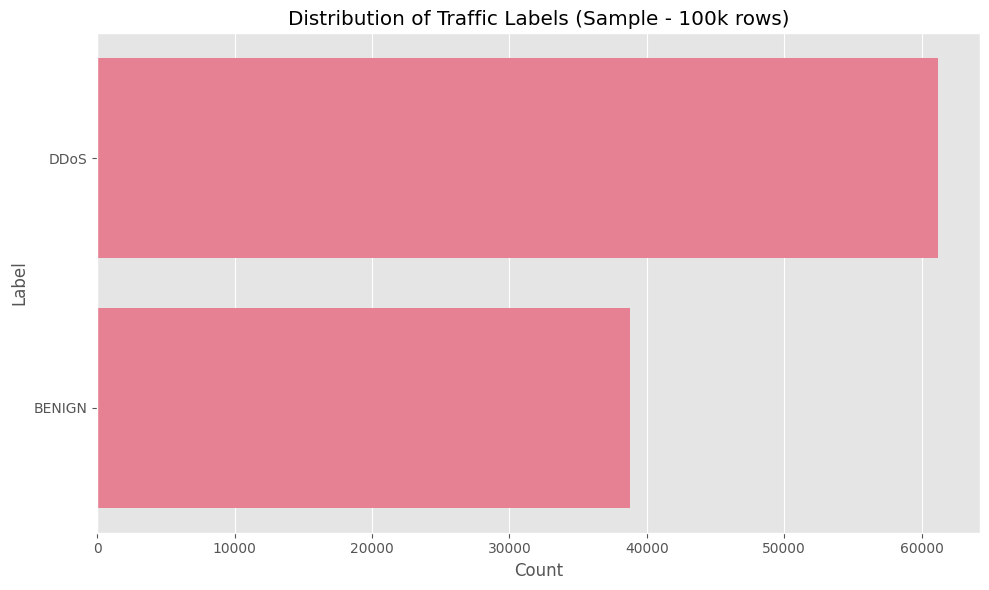

Label
DDoS      61194
BENIGN    38806
Name: count, dtype: int64


In [3]:
plt.figure(figsize=(10, 6))
label_counts = sample_df['Label'].value_counts()
sns.barplot(x=label_counts.values, y=label_counts.index, orient='h')
plt.title("Distribution of Traffic Labels (Sample - 100k rows)")
plt.xlabel("Count")
plt.tight_layout()
plt.show()
print(label_counts)

## 3. Traffic Volume Over Time
We group synthesized flows into 1-minute bins to see "attack bursts" over time.

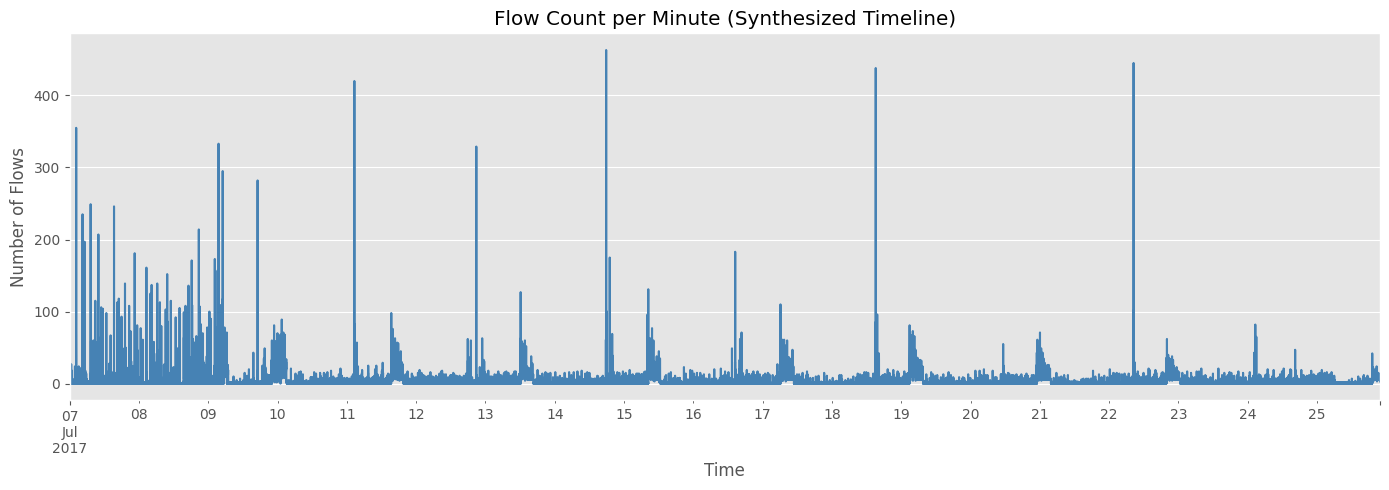

In [4]:
# The Timestamp column was synthesized in the load step above
time_counts = sample_df.resample('1min', on='Timestamp').size()

plt.figure(figsize=(14, 5))
time_counts.plot(color='steelblue')
plt.title("Flow Count per Minute (Synthesized Timeline)")
plt.ylabel("Number of Flows")
plt.xlabel("Time")
plt.tight_layout()
plt.show()

## 4. Feature Correlations with Attack Label
Checking which flow attributes (e.g., Packet Size, IAT) correlate most with attacks.

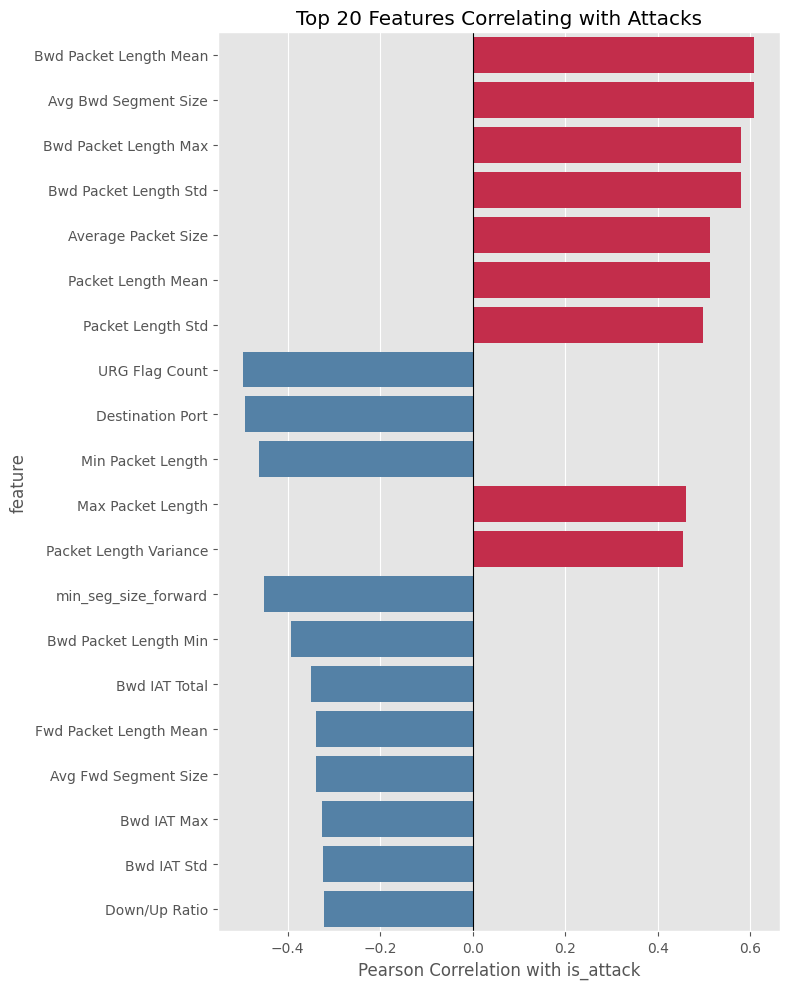

In [5]:
sample_df['is_attack'] = (sample_df['Label'] != 'BENIGN').astype(int)

# Drop non-numeric and the Timestamp we added
numeric_df = sample_df.select_dtypes(include=[np.number])
corr = numeric_df.corr()['is_attack'].drop('is_attack').sort_values(key=abs, ascending=False)

top20 = corr.head(20)

# Fix: use hue + legend=False instead of palette= (seaborn v0.14 deprecation)
top20_df = top20.reset_index()
top20_df.columns = ['feature', 'corr']
top20_df['color'] = ['crimson' if v > 0 else 'steelblue' for v in top20_df['corr']]
palette_map = {c: c for c in top20_df['color'].unique()}

plt.figure(figsize=(8, 10))
sns.barplot(data=top20_df, x='corr', y='feature', hue='color', palette=palette_map, legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Top 20 Features Correlating with Attacks")
plt.xlabel("Pearson Correlation with is_attack")
plt.tight_layout()
plt.show()


## 5. Model Comparison Results
Compare the trained models using the correct metrics: ROC-AUC and F1-Score.

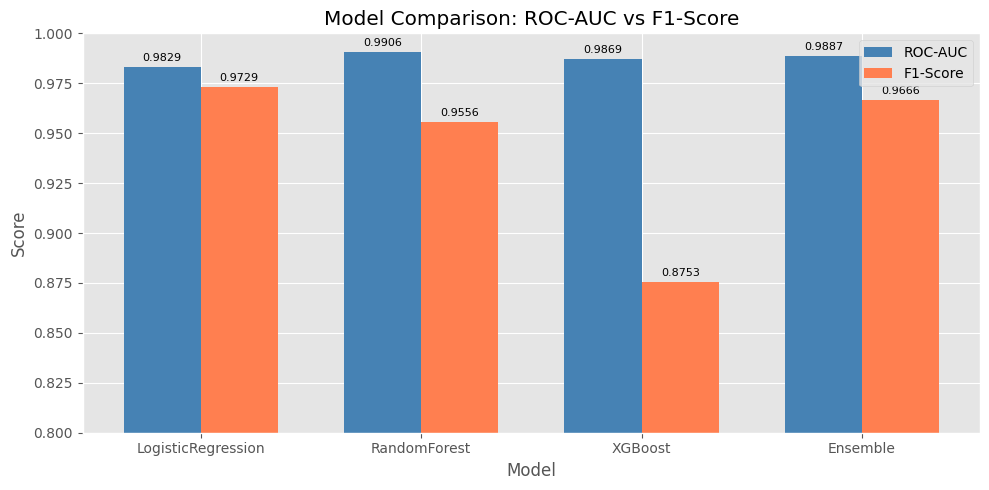

Model                        ROC-AUC   F1-Score
-----------------------------------------------
LogisticRegression            0.9829     0.9729
RandomForest                  0.9906     0.9556
XGBoost                       0.9869     0.8753
Ensemble                      0.9887     0.9666


In [6]:
import json

metrics_path = '../models/metrics.json'
with open(metrics_path) as f:
    metrics = json.load(f)

model_names = list(metrics.keys())
roc_scores  = [metrics[m]['ROC_AUC'] for m in model_names]
f1_scores   = [metrics[m]['F1_Score'] for m in model_names]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, roc_scores, width, label='ROC-AUC', color='steelblue')
bars2 = ax.bar(x + width/2, f1_scores,  width, label='F1-Score', color='coral')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: ROC-AUC vs F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0.8, 1.0)
ax.legend()
ax.bar_label(bars1, padding=3, fmt='%.4f', fontsize=8)
ax.bar_label(bars2, padding=3, fmt='%.4f', fontsize=8)
plt.tight_layout()
plt.show()

# Print table
print(f"{'Model':<25} {'ROC-AUC':>10} {'F1-Score':>10}")
print("-" * 47)
for name in model_names:
    print(f"{name:<25} {metrics[name]['ROC_AUC']:>10.4f} {metrics[name]['F1_Score']:>10.4f}")